In [ ]:
using Pkg
Pkg.activate(".")
Pkg.resolve()

In [ ]:
using Base64, JSON, CUDA, Printf, LinearAlgebra, Random
include("../src/NeuroDSL.jl")
using .NeuroDSL

In [4]:
function run_pedagogical_demo()
    # 1. Initialisation
    ns = :demo_branch
    g = NeuroGraph(namespace=ns)
    dev = g.device
    
    println("🏗️ Construction du réseau à double bras...")
    
    # Entrée commune
    set!(g, :X, randn(Float32, 1, 4); namespace=ns)
    
    # --- BRAS A (Le bras "Fusionné") ---
    # X -> Linear_A -> ReLU -> Out_A
    set!(g, :Wa, randn(Float32, 2, 4) .* 0.1f0; is_param=true, namespace=ns)
    set!(g, :ba, randn(Float32, 2); is_param=true, namespace=ns)
    addrule!(g, GraphRule(:z_a, [:X, :Wa, :ba], :linear; namespace=ns))
    addrule!(g, GraphRule(:a_a, [:z_a], :relu; namespace=ns))
    
    # --- BRAS B (Le bras "Simple") ---
    # X -> Linear_B -> Out_B
    set!(g, :Wb, randn(Float32, 2, 4) .* 0.1f0; is_param=true, namespace=ns)
    set!(g, :bb, randn(Float32, 2); is_param=true, namespace=ns)
    addrule!(g, GraphRule(:z_b, [:X, :Wb, :bb], :linear; namespace=ns))
    
    # --- FUSION ---
    println("⚡ Fusion du Bras A (Linear + ReLU)...")
    _fuse!(g, [:z_a, :a_a]; ns=ns) # z_a disparaît, a_a devient :fused_matmul_relu
    
    # --- SORTIE COMMUNE ---
    # Out_A + Out_B -> Loss
    addrule!(g, GraphRule(:sum, [:a_a, :z_b], :add; namespace=ns))
    addrule!(g, GraphRule(:loss, [:sum], :sum_matrix; namespace=ns))

    # ==========================================================================
    # SCÉNARIO 1 : Premier passage complet (Full Pass)
    # ==========================================================================
    println("\n🎬 Scénario 1 : Premier passage complet...")
    log1 = ExecutionLog()
    ctx1 = CtxStore()
    
    demand!(g, :loss; ctx_store=ctx1, log=log1, namespace=ns)
    backward_graph!(g, :loss; ctx_store=ctx1, full=true, log=log1, namespace=ns)
    
    save_interactive_graph(g, log1, "demo_full_pass.html"; title="Séquence 1: Passage Complet")

    # ==========================================================================
    # SCÉNARIO 2 : Modification chirurgicale du Bras B
    # ==========================================================================
    println("\n🛠️ Scénario 2 : Modification du Bras B uniquement...")
    
    # On change UNIQUEMENT le poids du bras B
    set!(g, :Wb, randn(Float32, 2, 4) .* 0.1f0; is_param=true, namespace=ns)
    
    log2 = ExecutionLog()
    ctx2 = CtxStore()
    
    # On lance un passage incrémental (full=false)
    demand!(g, :loss; ctx_store=ctx2, log=log2, namespace=ns)
    backward_graph!(g, :loss; ctx_store=ctx2, full=false, log=log2, namespace=ns)
    
    save_interactive_graph(g, log2, "demo_incremental_pass.html"; title="Séquence 2: Passage Incrémental (Bras B)")

    println("\n✅ Démo terminée !")
    println("👉 Regardez 'demo_full_pass.html' : Tout le graphe s'allume.")
    println("👉 Regardez 'demo_incremental_pass.html' : Seul le bras B et la loss s'allument !")
end

run_pedagogical_demo()

🏗️ Construction du réseau à double bras...
⚡ Fusion du Bras A (Linear + ReLU)...

🎬 Scénario 1 : Premier passage complet...
✅ Interactive Trace exporté → demo_full_pass.html

🛠️ Scénario 2 : Modification du Bras B uniquement...
✅ Interactive Trace exporté → demo_incremental_pass.html

✅ Démo terminée !
👉 Regardez 'demo_full_pass.html' : Tout le graphe s'allume.
👉 Regardez 'demo_incremental_pass.html' : Seul le bras B et la loss s'allument !


In [ ]:
# 1. Enregistrer les opérateurs personnalisés
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)

NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        @inbounds for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)

# 2. Construction du graphe Fibonacci
function build_fib_graph!(g, n; ns=:fib, vec_size=10)
    NeuroDSL.set!(g, :f0, randn(Float32, vec_size); namespace=ns)
    NeuroDSL.set!(g, :f1, randn(Float32, vec_size); namespace=ns)

    even_nodes = Symbol[:f0]        # f[0] est pair (indice 0)
    prev0, prev1 = :f0, :f1

    for i in 0:n-1
        f2 = Symbol(:f, i + 2)
        NeuroDSL.addrule!(g,
            NeuroDSL.GraphRule(f2, [prev0, prev1], :wsum; namespace=ns))
        prev0, prev1 = prev1, f2
        # i impair → f2 est à un indice pair
        i % 2 == 1 && push!(even_nodes, f2)
    end

    yn_sym = prev1      # dernier terme = f[n+1]

    # Nœud large : somme des termes pairs
    NeuroDSL.addrule!(g,
        NeuroDSL.GraphRule(:sn, even_nodes, :nsum; namespace=ns))

    return yn_sym, :sn
end

# 3. Exécution et benchmarking
n = 10
println("="^58)
@printf " NeuroDSL  Fibonacci DAG  n = %d\n" n
println("="^58)

t_build = @elapsed begin
    g = NeuroDSL.NeuroGraph(namespace=:fib, device=NeuroDSL.Backend.CPUDevice())
    yn_sym, sn_sym = build_fib_graph!(g, n; ns=:fib)
end
@printf "  Construction   %6d nœuds     %.4f s\n" (n+3) t_build

# Log d'exécution pour la visualisation
log = ExecutionLog()
ctx = CtxStore()

# Calcul de la somme des termes pairs (sn) et du dernier terme (yn)
NeuroDSL.invalidate_all!(g; namespace=:fib)
NeuroDSL.demand!(g, sn_sym; ctx_store=ctx, namespace=:fib, log=log)
NeuroDSL.demand!(g, yn_sym; ctx_store=ctx, namespace=:fib, log=log)

# Affichage des résultats
sn_val = Array(NeuroDSL.node(g, :sn; namespace=:fib).value)
yn_val = Array(NeuroDSL.node(g, yn_sym; namespace=:fib).value)
@printf "  sn (wide)  : [%.4f, %.4f, ...]\n" sn_val[1] sn_val[2]
@printf "  yn (deep)  : [%.4f, %.4f, ...]\n" yn_val[1] yn_val[2]

# Génération du fichier HTML interactif
save_interactive_graph(g, log, "fibonacci_n10.html"; title="Fibonacci DAG (n=10)")

println("\n✅ Visualisation sauvegardée dans fibonacci_n10.html")

In [ ]:


# 1. Opérateurs personnalisés
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)

# 2. Construction du graphe (vec_size = 1 pour des scalaires)
function build_fib_graph!(g, n; ns=:fib, vec_size=1)
    NeuroDSL.set!(g, :f0, Float32[1.0]; namespace=ns)   # f0 = 1.0
    NeuroDSL.set!(g, :f1, Float32[2.0]; namespace=ns)   # f1 = 2.0

    even_nodes = Symbol[:f0]
    prev0, prev1 = :f0, :f1
    for i in 0:n-1
        f2 = Symbol(:f, i+2)
        NeuroDSL.addrule!(g, NeuroDSL.GraphRule(f2, [prev0, prev1], :wsum; namespace=ns))
        prev0, prev1 = prev1, f2
        if i % 2 == 0  
            push!(even_nodes, f2)
        end
    end
    yn_sym = prev1
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:sn, even_nodes, :nsum; namespace=ns))
    return yn_sym, :sn
end

# 3. Exécution
n = 8
g = NeuroDSL.NeuroGraph(namespace=:fib, device=NeuroDSL.Backend.CPUDevice())
yn_sym, sn_sym = build_fib_graph!(g, n)

log = ExecutionLog()
ctx = CtxStore()

NeuroDSL.demand!(g, sn_sym; ctx_store=ctx, namespace=:fib, log=log)
NeuroDSL.demand!(g, yn_sym; ctx_store=ctx, namespace=:fib, log=log)

# 4. Affichage de tous les f_i et des résultats
println("=== Vérification des calculs (n = $n) ===")
for sym in [:f0, :f1, :f2, :f3, :f4, :f5, :f6, :sn]
    if haskey(g.nodes[:fib], sym)
        val = Array(g.nodes[:fib][sym].value)
        println("$sym = ", val)
    end
end


println("\nAttendu : f2=1.7, f3=1.79, f4=1.763, f5=1.7711, f6≈1.7687, sn≈4.463")

# 6. Visualisation interactive
save_interactive_graph(g, log, "fibonacci_n5_simple.html"; title="Fibonacci DAG (n=5, scalars)")
println("\n✅ Visualisation sauvegardée dans fibonacci_n5_simple.html")

In [8]:


# 1. Enregistrer les opérateurs (si ce n'est déjà fait)
NeuroDSL.register_op!(:wsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) ->
        (@. out = 0.3f0 * inputs[1] + 0.7f0 * inputs[2])
)
NeuroDSL.register_op!(:nsum,
    (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
        copyto!(out, inputs[1])
        for i in 2:length(inputs)
            out .+= inputs[i]
        end
    end
)

# 2. Construction du graphe (version avec addrule!)
function build_fib_graph!(g, n; ns=:fib, vec_size=1)
    NeuroDSL.set!(g, :f0, Float32[1.0]; namespace=ns)   # f0 = 1.0
    NeuroDSL.set!(g, :f1, Float32[2.0]; namespace=ns)   # f1 = 2.0

    even_nodes = Symbol[:f0]        # f0 est pair
    prev0, prev1 = :f0, :f1

    for i in 0:n-1
        f2 = Symbol(:f, i+2)
        NeuroDSL.addrule!(g,
            NeuroDSL.GraphRule(f2, [prev0, prev1], :wsum; namespace=ns))
        prev0, prev1 = prev1, f2
        i % 2 == 1 && push!(even_nodes, f2)   # f2 d'indice pair
    end

    yn_sym = prev1      # dernier terme = f[n+1]
    NeuroDSL.addrule!(g,
        NeuroDSL.GraphRule(:sn, even_nodes, :nsum; namespace=ns))

    return yn_sym, :sn
end

# 3. Exécution et vérification
n = 6
g = NeuroDSL.NeuroGraph(namespace=:fib, device=NeuroDSL.Backend.CPUDevice())
yn_sym, sn_sym = build_fib_graph!(g, n)

log = ExecutionLog()
ctx = CtxStore()

NeuroDSL.demand!(g, sn_sym; ctx_store=ctx, namespace=:fib, log=log)
NeuroDSL.demand!(g, yn_sym; ctx_store=ctx, namespace=:fib, log=log)

# Affichage des résultats
println("=== Vérification des calculs (n = $n) ===")
for sym in [:f0, :f1, :f2, :f3, :f4, :f5, :f6, :sn]
    if haskey(g.nodes[:fib], sym)
        val = Array(g.nodes[:fib][sym].value)
        println("$sym = ", val)
    end
end
println("\nAttendu : f2=1.7, f3=1.79, f4=1.763, f5=1.7711, f6≈1.7687, sn≈4.463")

# Visualisation interactive
NeuroDSL.save_interactive_graph(g, log, "fibonacci_n6_simple.html"; title="Fibonacci DAG (n=6, scalars)")
println("\n✅ Visualisation sauvegardée dans fibonacci_n6_simple.html")

✅ Op :wsum enregistré
✅ Op :nsum enregistré
=== Vérification des calculs (n = 6) ===
f0 = Float32[1.0]
f1 = Float32[2.0]
f2 = Float32[1.7]
f3 = Float32[1.7900001]
f4 = Float32[1.763]
f5 = Float32[1.7711]
f6 = Float32[1.7686701]
sn = Float32[6.330499]

Attendu : f2=1.7, f3=1.79, f4=1.763, f5=1.7711, f6≈1.7687, sn≈4.463
✅ Interactive Trace exporté → fibonacci_n6_simple.html

✅ Visualisation sauvegardée dans fibonacci_n6_simple.html


In [ ]:
# Opérations élémentaires (non présentes par défaut)
NeuroDSL.register_op!(:sin,   (dev, out, inputs, attrs, out_sym, nd, ctx) -> out .= sin.(inputs[1]))
NeuroDSL.register_op!(:cos,   (dev, out, inputs, attrs, out_sym, nd, ctx) -> out .= cos.(inputs[1]))
NeuroDSL.register_op!(:exp,   (dev, out, inputs, attrs, out_sym, nd, ctx) -> out .= exp.(inputs[1]))
NeuroDSL.register_op!(:square,(dev, out, inputs, attrs, out_sym, nd, ctx) -> out .= inputs[1].^2)
NeuroDSL.register_op!(:neg,   (dev, out, inputs, attrs, out_sym, nd, ctx) -> out .= -inputs[1])

In [ ]:
function build_expression_graph()
    ns = :expr
    g = NeuroDSL.NeuroGraph(namespace=ns, device=NeuroDSL.Backend.CPUDevice())

    # Feuilles (entrées)
    NeuroDSL.set!(g, :x, Float32[0.5]; namespace=ns)
    NeuroDSL.set!(g, :y, Float32[2.0]; namespace=ns)
    NeuroDSL.set!(g, :z, Float32[1.0]; namespace=ns)

    # Règles de l'expression
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t1, [:x, :z], :add;    namespace=ns))   # x+z
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t2, [:t1],    :sin;    namespace=ns))   # sin(x+z)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t3, [:y, :t2], :mul;    namespace=ns))   # y * sin(x+z)

    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t4, [:z],      :square; namespace=ns))   # z^2
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t5, [:t4],     :neg;    namespace=ns))   # -z^2
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t6, [:t5],     :exp;    namespace=ns))   # exp(-z^2)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:t7, [:x, :t6], :mul;    namespace=ns))   # x * exp(-z^2)

    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:out, [:t3, :t7], :add;  namespace=ns))   # somme finale

    return g, :out
end

In [ ]:
g, out_sym = build_expression_graph()

log  = NeuroDSL.ExecutionLog()
ctx  = NeuroDSL.CtxStore()
NeuroDSL.demand!(g, out_sym; ctx_store=ctx, namespace=:expr, log=log)

val = Array(NeuroDSL.node(g, out_sym; namespace=:expr).value)[]
println("Résultat NeuroDSL : ", val)

# Vérification manuelle
x, y, z = 0.5f0, 2.0f0, 1.0f0
expected = y * sin(x + z) + x * exp(-z^2)
println("Valeur attendue   : ", expected)

In [ ]:
save_interactive_graph(g, log, "expression_example.html"; title="y·sin(x+z) + x·e^{-z²}")
println("✅ Graphe exporté dans expression_example.html")

In [ ]:
using Printf, LinearAlgebra

# ── Construction du MLP ──────────────────────────────────────────────────────
function build_mlp_graph()
    ns = :mlp_test
    dev = NeuroDSL.Backend.CPUDevice()
    g = NeuroDSL.NeuroGraph(device=dev, namespace=ns)

    NeuroDSL.set!(g, :X, Float32[1.0 2.0; 3.0 4.0])
    NeuroDSL.set!(g, :Y, Float32[0.5; 0.8])

    h1   = NeuroDSL.Linear(2, 3, bias=false)(g, :X, :fc1; namespace=ns)
    a1   = :relu1
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(a1, [h1], :relu; namespace=ns))
    h2   = NeuroDSL.Linear(3, 1, bias=false)(g, a1, :fc2; namespace=ns)
    loss = :loss
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(loss, [h2, :Y], :mse_loss; namespace=ns))

    return g, loss
end

# ── Moments AdamW ────────────────────────────────────────────────────────────
function init_moments(g, ns)
    dev = g.device
    Dict{Symbol,Tuple}(sym => (NeuroDSL.Backend.zeros32(dev, size(nd.value)...),
                               NeuroDSL.Backend.zeros32(dev, size(nd.value)...))
         for (sym, nd) in g.nodes[ns] if nd.is_param)
end

# ── Entraînement sur 2 itérations ────────────────────────────────────────────
g, loss_sym = build_mlp_graph()
ns = :mlp_test
dev = g.device
mom = init_moments(g, ns)
lr = 0.01f0
b1, b2, eps_v, wd, clip = 0.9f0, 0.999f0, 1f-8, 0.0f0, 1f0
ctx = NeuroDSL.CtxStore()
log = NeuroDSL.ExecutionLog()

println("="^50)
println("  MLP 2 couches — 2 itérations d'entraînement")
println("="^50)

for t in 1:2
    # Forward + backward
    NeuroDSL.invalidate_all!(g; namespace=ns)
    NeuroDSL.demand!(g, loss_sym; ctx_store=ctx, namespace=ns, log=log)
    loss_val = Array(NeuroDSL.node(g, loss_sym; namespace=ns).value)[1]
    # ▼▼▼ AJOUT DE log=log ▼▼▼
    NeuroDSL.backward_graph!(g, loss_sym; ctx_store=ctx, namespace=ns, full=true, log=log)

    println("\n--- Itération $t ---")
    @printf "  Loss = %.6f\n" loss_val
    for (sym, nd) in g.nodes[ns]
        nd.is_param || continue
        grad_norm = nd.gradient !== nothing ? norm(Array(nd.gradient)) : 0.0
        @printf "  %-10s  ||grad|| = %.6f\n" string(sym) grad_norm
    end

    # Mise à jour AdamW
    for (sym, nd) in g.nodes[ns]
        nd.is_param && nd.gradient !== nothing || continue
        m1, m2 = mom[sym]
        NeuroDSL.adamw_step!(dev, nd.value, nd.gradient, m1, m2,
                             lr, b1, b2, eps_v, Int32(t), clip, wd)
    end
end

# ── Visualisation ────────────────────────────────────────────────────────────
save_interactive_graph(g, log, "mlp_training.html"; title="MLP 2 couches — 2 itérations")
println("\n✅ Visualisation exportée dans mlp_training.html")

# Iris 

In [ ]:
using Random, Printf, Statistics, LinearAlgebra
using DataFrames
using MLDatasets: Iris
import Logging; Logging.disable_logging(Logging.Warn)

# ── Reproductibilité ───────────────────────────────────────
const SEED = 2024
Random.seed!(SEED)
const rng = MersenneTwister(SEED)

# ── Chargement Iris ────────────────────────────────────────
iris = Iris(as_df=false)
X_all = Float32.(iris.features)
X_all = permutedims(X_all)          # 150×4
y_labels = collect(iris.targets)

unique_labels = sort(unique(y_labels))
label_to_int = Dict(label => i-1 for (i, label) in enumerate(unique_labels))
y_all = Int[label_to_int[label] for label in y_labels]

# One‑hot
Y_all = zeros(Float32, size(X_all, 1), 3)
for i in axes(Y_all, 1)
    Y_all[i, y_all[i]+1] = 1.0f0
end

# Split déterministe
idx = randperm(rng, size(X_all, 1))
X_train, Y_train = X_all[idx[1:100], :], Y_all[idx[1:100], :]
X_test,  Y_test  = X_all[idx[101:end], :], Y_all[idx[101:end], :]

# ── Modèle amélioré (biais + 16 neurones) ─────────────────
function build_iris_mlp()
    ns = :iris
    dev = NeuroDSL.Backend.CPUDevice()
    g = NeuroDSL.NeuroGraph(device=dev, namespace=ns)
    NeuroDSL.set!(g, :X, zeros(Float32, 32, 4))
    NeuroDSL.set!(g, :Y, zeros(Float32, 32, 3))
    # biais activé par défaut (bias=true)
    h1 = NeuroDSL.Linear(4, 16)(g, :X, :fc1; namespace=ns)
    a1 = :relu1
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(a1, [h1], :relu; namespace=ns))
    h2 = NeuroDSL.Linear(16, 3)(g, a1, :fc2; namespace=ns)
    loss_sym = :loss
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(loss_sym, [h2, :Y], :mse_loss; namespace=ns))
    return g, loss_sym
end

function init_moments(g, ns)
    dev = g.device
    Dict{Symbol,Tuple}(sym => (NeuroDSL.Backend.zeros32(dev, size(nd.value)...),
                               NeuroDSL.Backend.zeros32(dev, size(nd.value)...))
         for (sym, nd) in g.nodes[ns] if nd.is_param)
end

# ── Entraînement ───────────────────────────────────────────
BATCH_SIZE = 32
g, loss_sym = build_iris_mlp()
ns = :iris
dev = g.device
mom = init_moments(g, ns)
lr = 0.05f0                     # plus agressif
b1, b2, eps_v, wd, clip = 0.9f0, 0.999f0, 1f-8, 0.0f0, 1f0
ctx = NeuroDSL.CtxStore()

epochs = 100
n_train = size(X_train, 1)

recorder = TrainingRecorder(; capture_epochs=[1, 10, 25, 50, 75, 100])
losses = Float32[]

println("Entraînement Iris ($epochs époques) – biais + 16 neurones")

for epoch in 1:epochs
    perm = randperm(rng, n_train)
    X_tr = X_train[perm, :]
    Y_tr = Y_train[perm, :]

    total_loss = 0.0f0
    for start in 1:BATCH_SIZE:n_train
        batch_end = min(start + BATCH_SIZE - 1, n_train)
        Xb = X_tr[start:batch_end, :]
        Yb = Y_tr[start:batch_end, :]
        bs = size(Xb, 1)

        if bs < BATCH_SIZE
            g.nodes[ns][:X].value = zeros(Float32, bs, 4)
            g.nodes[ns][:Y].value = zeros(Float32, bs, 3)
        else
            g.nodes[ns][:X].value = zeros(Float32, BATCH_SIZE, 4)
            g.nodes[ns][:Y].value = zeros(Float32, BATCH_SIZE, 3)
        end
        copyto!(g.nodes[ns][:X].value, Array(Xb))
        copyto!(g.nodes[ns][:Y].value, Array(Yb))

        local_log = should_capture(recorder, epoch) ? NeuroDSL.ExecutionLog() : nothing
        NeuroDSL.invalidate_all!(g; namespace=ns)
        NeuroDSL.demand!(g, loss_sym; ctx_store=ctx, namespace=ns, log=local_log)
        loss_val = Array(NeuroDSL.node(g, loss_sym; namespace=ns).value)[1]
        total_loss += loss_val * bs
        NeuroDSL.backward_graph!(g, loss_sym; ctx_store=ctx, namespace=ns, full=true, log=local_log)

        for (sym, nd) in g.nodes[ns]
            nd.is_param && nd.gradient !== nothing || continue
            m1, m2 = mom[sym]
            NeuroDSL.adamw_step!(dev, nd.value, nd.gradient, m1, m2,
                                 lr, b1, b2, eps_v, Int32(epoch), clip, wd)
        end

        if local_log !== nothing
            push!(recorder.snapshots, TrainingSnapshot(epoch, start, loss_val, local_log))
        end
    end
    avg_loss = total_loss / n_train
    push!(losses, avg_loss)
    if epoch % 10 == 0 || epoch == 1
        @printf "Epoch %3d  loss = %.4f\n" epoch avg_loss
    end
end

# ── Évaluation ─────────────────────────────────────────────
g.nodes[ns][:X].value = zeros(Float32, size(X_test, 1), 4)
g.nodes[ns][:Y].value = zeros(Float32, size(Y_test, 1), 3)
copyto!(g.nodes[ns][:X].value, Array(X_test))
copyto!(g.nodes[ns][:Y].value, Array(Y_test))
NeuroDSL.invalidate_all!(g; namespace=ns)
NeuroDSL.demand!(g, loss_sym; ctx_store=ctx, namespace=ns)

h2_val = Array(NeuroDSL.node(g, :fc2_out; namespace=ns).value)
preds = vec(argmax(h2_val, dims=2))
true_labels = vec(argmax(Y_test, dims=2))
accuracy = mean(preds .== true_labels)
println("Test accuracy = $(round(accuracy*100, digits=1))%")

# ── Visualisation ──────────────────────────────────────────
save_interactive_graph_animated(
    g,
    recorder.snapshots,
    "iris_training_anim.html";
    title = "Iris MLP – biais + 16 neurones ($epochs époques)",
    losses = losses
)
println("✅ Visualisation exportée → iris_training_anim.html")

In [ ]:
using Printf, LinearAlgebra, Random

# ═══════════════════════════════════════════════════════════
# DATASET — approximation de sin(2πx) sur [0,1]
# ═══════════════════════════════════════════════════════════
function make_sinus_dataset(n::Int=200)
    Random.seed!(42)
    x = sort(rand(Float32, n))
    y = sin.(2f0 * Float32(π) .* x) .+ 0.05f0 .* randn(Float32, n)
    # Normalise y dans [-1, 1] → déjà le cas pour sin
    # X reshape : (n, 1), Y reshape : (n, 1)
    X = reshape(x, n, 1)
    Y = reshape(y, n, 1)
    return X, Y
end

function make_batches(X, Y, batch_size::Int)
    n = size(X, 1)
    idx = shuffle(1:n)
    X_s, Y_s = X[idx, :], Y[idx, :]
    [(X_s[i:min(i+batch_size-1,n), :], Y_s[i:min(i+batch_size-1,n), :])
     for i in 1:batch_size:n]
end

# ═══════════════════════════════════════════════════════════
# GRAPHE MLP — 1 → 32 → 32 → 1 (ReLU)
# ═══════════════════════════════════════════════════════════
function build_sinus_mlp(batch_size::Int)
    ns  = :sinus_mlp
    dev = NeuroDSL.Backend.CPUDevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)

    NeuroDSL.set!(g, :X, zeros(Float32, batch_size, 1); namespace=ns)
    NeuroDSL.set!(g, :Y, zeros(Float32, batch_size, 1);
                  atom_type=NeuroDSL.Datom, namespace=ns)

    h1  = NeuroDSL.Linear(1, 32, bias=true)(g, :X,  :fc1; namespace=ns)
    a1  = :relu1
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(a1, [h1], :relu; namespace=ns))

    h2  = NeuroDSL.Linear(32, 32, bias=true)(g, a1, :fc2; namespace=ns)
    a2  = :relu2
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(a2, [h2], :relu; namespace=ns))

    out = NeuroDSL.Linear(32, 1, bias=true)(g, a2, :fc3; namespace=ns)

    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [out, :Y], :mse_loss; namespace=ns))

    return g, out, ns
end

function init_moments(g, ns)
    dev = g.device
    Dict{Symbol,Tuple}(
        sym => (NeuroDSL.Backend.zeros32(dev, size(nd.value)...),
                NeuroDSL.Backend.zeros32(dev, size(nd.value)...))
        for (sym, nd) in g.nodes[ns] if nd.is_param)
end

# ═══════════════════════════════════════════════════════════
# ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════════
println("📐 Génération du dataset sin(2πx)...")
X_all, Y_all = make_sinus_dataset(300)
# Split train/test
X_tr, Y_tr = X_all[1:240, :], Y_all[1:240, :]
X_te, Y_te = X_all[241:end, :], Y_all[241:end, :]
println("✅ Train: $(size(X_tr,1)) | Test: $(size(X_te,1))")

BATCH   = 32
EPOCHS = 500
LR     = 0.003f0

g, out_sym, ns = build_sinus_mlp(BATCH)
dev = g.device
mom = init_moments(g, ns)
ctx = NeuroDSL.CtxStore()
log_final = NeuroDSL.ExecutionLog()   # log de la dernière epoch seulement

println("\n🚀 Entraînement MLP sur sin(2πx) — $EPOCHS epochs...")
println("="^50)

t = 0
for epoch in 1:EPOCHS
    # Décroissance du LR après epoch 300
    lr_epoch = epoch < 300 ? LR : LR * 0.1f0
    
    batches    = make_batches(X_tr, Y_tr, BATCH)
    epoch_loss = 0f0

    for (xb, yb) in batches
        t += 1
        bs = size(xb, 1)
        if bs < BATCH
            xb = vcat(xb, zeros(Float32, BATCH-bs, 1))
            yb = vcat(yb, zeros(Float32, BATCH-bs, 1))
        end

        g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
        g.nodes[ns][:Y].value = yb; g.nodes[ns][:Y].valid = true

        NeuroDSL.invalidate_all!(g; namespace=ns)
        ctx_b = NeuroDSL.CtxStore()
        NeuroDSL.demand!(g, :loss; ctx_store=ctx_b, namespace=ns)
        epoch_loss += g.nodes[ns][:loss].value[1]
        NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx_b, namespace=ns, full=true)

        for (sym, nd) in g.nodes[ns]
            nd.is_param && nd.gradient !== nothing || continue
            m1, m2 = mom[sym]
            NeuroDSL.adamw_step!(dev, nd.value, nd.gradient, m1, m2,
                                 lr_epoch, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)
        end
    end

    avg_loss = epoch_loss / length(batches)
    if epoch == 1 || epoch % 50 == 0
        @printf "  Epoch %3d | Loss: %.6f | LR: %.4f\n" epoch avg_loss lr_epoch
    end
end

# ── Dernier forward+backward loggé pour la visualisation ──
println("\n📸 Capture du graphe pour visualisation...")
xb_vis = X_tr[1:BATCH, :]
yb_vis = Y_tr[1:BATCH, :]
g.nodes[ns][:X].value = xb_vis; g.nodes[ns][:X].valid = true
g.nodes[ns][:Y].value = yb_vis; g.nodes[ns][:Y].valid = true
NeuroDSL.invalidate_all!(g; namespace=ns)
ctx_vis = NeuroDSL.CtxStore()
NeuroDSL.demand!(g, :loss; ctx_store=ctx_vis, namespace=ns, log=log_final)
NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx_vis, namespace=ns, full=true, log=log_final)

# ── Évaluation test ────────────────────────────────────────
println("\n📊 Évaluation sur le test set...")
test_loss = 0f0
n_batches_te = 0
for i in 1:BATCH:size(X_te,1)
    xb = X_te[i:min(i+BATCH-1,end), :]
    yb = Y_te[i:min(i+BATCH-1,end), :]
    bs = size(xb,1)
    if bs < BATCH
        xb = vcat(xb, zeros(Float32, BATCH-bs, 1))
        yb = vcat(yb, zeros(Float32, BATCH-bs, 1))
    end
    g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
    g.nodes[ns][:Y].value = yb; g.nodes[ns][:Y].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    ctx_t = NeuroDSL.CtxStore()
    NeuroDSL.demand!(g, :loss; ctx_store=ctx_t, namespace=ns)
    test_loss += g.nodes[ns][:loss].value[1]
    n_batches_te += 1
end
@printf "  Test MSE : %.6f\n" (test_loss / n_batches_te)

# ── Quelques prédictions vs vérité ────────────────────────
println("\n  x       sin(2πx)   prédiction")
println("  " * "-"^35)
for x_val in [0.0f0, 0.1f0, 0.25f0, 0.5f0, 0.75f0, 1.0f0]
    xb = fill(x_val, BATCH, 1)
    g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    ctx_p = NeuroDSL.CtxStore()
    pred = NeuroDSL.demand!(g, out_sym; ctx_store=ctx_p, namespace=ns)
    y_true = sin(2f0 * Float32(π) * x_val)
    y_pred = pred[1, 1]
    @printf "  %.2f    %+.4f     %+.4f\n" x_val y_true y_pred
end

# ── Export visualisation ───────────────────────────────────
println("\n🎨 Export de la visualisation...")
save_interactive_graph(g, log_final, "sinus_mlp.html";
                       title="MLP sin(2πx) — après $EPOCHS epochs")
println("✅ Visualisation exportée → sinus_mlp.html")

In [ ]:
# ── Courbe de comparaison sin(2πx) vs MLP ─────────────────
x_plot = collect(range(0f0, 1f0, length=200))
y_true = sin.(2f0 .* Float32(π) .* x_plot)
y_pred = Float32[]

for x_val in x_plot
    xb = fill(x_val, BATCH, 1)
    g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    ctx_p = NeuroDSL.CtxStore()
    pred = NeuroDSL.demand!(g, out_sym; ctx_store=ctx_p, namespace=ns)
    push!(y_pred, pred[1,1])
end

# Convertit en JSON manuellement
x_js     = "[" * join([@sprintf("%.4f", v) for v in x_plot],  ",") * "]"
true_js  = "[" * join([@sprintf("%.4f", v) for v in y_true],  ",") * "]"
pred_js  = "[" * join([@sprintf("%.4f", v) for v in y_pred],  ",") * "]"

open("sinus_fit.html", "w") do f
    write(f, """
<!DOCTYPE html><html><head><meta charset="UTF-8">
<title>MLP vs sin(2πx)</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<style>
  body { background:#0f1117; display:flex; flex-direction:column;
         justify-content:center; align-items:center;
         height:100vh; margin:0; font-family:sans-serif; }
  h2   { color:#e2e8f0; margin-bottom:16px; font-size:1.1rem; }
  .wrap{ width:90vw; max-width:900px; }
</style></head><body>
<h2>MLP NeuroDSL — approximation de sin(2πx)</h2>
<div class="wrap"><canvas id="c"></canvas></div>
<script>
const xVals = $x_js;
const yTrue = $true_js;
const yPred = $pred_js;

new Chart(document.getElementById('c'), {
  type: 'line',
  data: {
    labels: xVals,
    datasets: [
      { label: 'sin(2πx) réel',
        data: yTrue,
        borderColor: '#22c55e',
        borderWidth: 2.5,
        pointRadius: 0,
        tension: 0.4,
        fill: false },
      { label: 'MLP NeuroDSL',
        data: yPred,
        borderColor: '#f59e0b',
        borderWidth: 2.5,
        borderDash: [6,3],
        pointRadius: 0,
        tension: 0.4,
        fill: false }
    ]
  },
  options: {
    responsive: true,
    animation: false,
    plugins: {
      legend: { labels: { color:'#e2e8f0', font:{ size:13 } } }
    },
    scales: {
      x: { ticks:{ color:'#94a3b8', maxTicksLimit:11,
                   callback: (v,i) => i % 20 === 0 ? xVals[i].toFixed(2) : '' },
           grid: { color:'#1e293b' } },
      y: { ticks:{ color:'#94a3b8' },
           grid: { color:'#1e293b' },
           min: -1.4, max: 1.4 }
    }
  }
});
</script></body></html>
""")
end
println("✅ Courbe exportée → sinus_fit.html")

In [ ]:
using Plots

x_plot = collect(range(0f0, 1f0, length=200))
y_true = sin.(2f0 .* Float32(π) .* x_plot)
y_pred = Float32[]

for x_val in x_plot
    xb = fill(x_val, BATCH, 1)
    g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
    NeuroDSL.invalidate_all!(g; namespace=ns)
    ctx_p = NeuroDSL.CtxStore()
    pred = NeuroDSL.demand!(g, out_sym; ctx_store=ctx_p, namespace=ns)
    push!(y_pred, pred[1,1])
end

plot(x_plot, y_true, label="sin(2πx) réel",  lw=2, color=:green)
plot!(x_plot, y_pred, label="MLP NeuroDSL",  lw=2, color=:orange, linestyle=:dash)
scatter!(X_tr[:,1], Y_tr[:,1], label="données train", ms=2, alpha=0.3, color=:gray)
title!("MLP NeuroDSL vs sin(2πx) — 500 epochs ReLU")
xlabel!("x"); ylabel!("y")

# Tanh 

In [1]:
# Chargement conditionnel de NeuroDSL
if !isdefined(Main, :NeuroDSL)
    push!(LOAD_PATH, "../src")
    using NeuroDSL
else
    @warn "NeuroDSL already loaded, using existing instance"
end

In [1]:
using NeuroDSL

┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API C:\Users\Nevermind\.julia\juliaup\julia-1.10.4+0.x64.w64.mingw32\share\julia\stdlib\v1.10\Pkg\src\API.jl:1807
┌ Warning: Circular dependency detected. Precompilation will be skipped for:
│   cuSPARSE [b26da814-b3bc-49ef-b0ee-c816305aa060]
│   ChainRulesCoreExt [8ccf546c-b5ad-5491-b9b6-b62e2a4db961]
│   GPUArraysSparseArraysExt [555d850b-e4ac-5d9d-bfa0-17bb432b4efb]
│   ChainRules [082447d4-558c-5d27-93f4-14fc19e9eca2]
│   NVML [611af6d1-644e-4c5d-bd58-854d7d1254b9]
│   GPUArrays [0c68f7d7-f131-5f86-a1c3-88cf8149b2d7]
│   KernelAbstractions [63c18a36-062a-441e-b654-da1e3ab1ce7c]
│   ZygoteExt [3f48baa7-5843-56cc-8004-b8b725de387b]
│   FluxCUDAExt [dd41ee52-2073-581e-92e8-26baf003f19a]
│   cuSOLVER [887afef0-6a32-4de5-add4-7827692ba8fc]
│   CUDAExt [9e0aca61-9665-56cf-9642-d947ef6fc392]
│ 

✅ Op :tanh enregistré
✅ Op :tanh + gradient enregistrés
📐 Génération du dataset sin(2πx)...
✅ Train: 240 | Test: 60

  🔴 tanh — 1→64→64→1 — 500 epochs (capture snapshots)
  Epoch   1 | Loss: 0.473137 | LR: 0.00500
  Epoch  50 | Loss: 0.002831 | LR: 0.00500
  Epoch 100 | Loss: 0.003337 | LR: 0.00500
  Epoch 150 | Loss: 0.003627 | LR: 0.00500
  Epoch 200 | Loss: 0.002690 | LR: 0.00500
  Epoch 250 | Loss: 0.002656 | LR: 0.00500
  Epoch 300 | Loss: 0.002505 | LR: 0.00050
  Epoch 350 | Loss: 0.002241 | LR: 0.00050
  Epoch 400 | Loss: 0.002240 | LR: 0.00050
  Epoch 450 | Loss: 0.002219 | LR: 0.00050
  Epoch 500 | Loss: 0.002234 | LR: 0.00050

🎨 Export visualisation animée de l'entraînement...
✅ Viewer animé exporté → training_anim_tanh.html  (48 snapshots)
✅ Visualisation exportée → training_anim_tanh.html


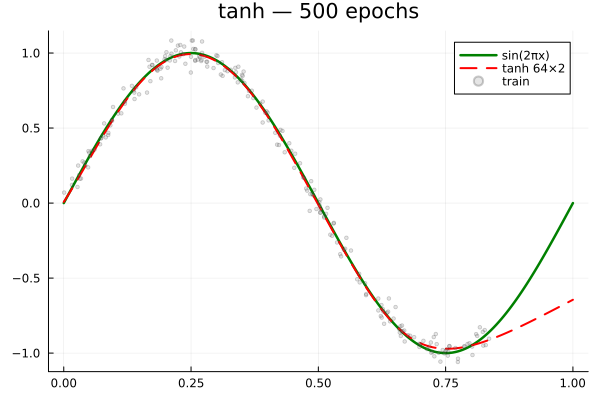

In [2]:
using Printf, Random, Plots, LinearAlgebra
import Logging; Logging.disable_logging(Logging.Warn)

push!(LOAD_PATH, "../src")
using NeuroDSL
import NeuroDSL: format_tensor_short, format_tensor_full

# Opérateur tanh
NeuroDSL.register_op!(:tanh,
    (dev, output_buffer, inputs, attrs, out_sym, out_node, ctx_store) -> begin
        x = inputs[1]
        output_buffer .= tanh.(x)
        if ctx_store !== nothing
            ctx_store[out_sym] = Dict{Symbol,Any}(:x => x)
        end
    end
)
NeuroDSL.GRAD_RULES[:tanh] = (dev, grad_out, ctx, inputs) -> begin
    x = inputs[1]
    [grad_out .* (1f0 .- tanh.(x).^2)]
end
println("✅ Op :tanh + gradient enregistrés")

# Dataset
function make_sinus_dataset(n::Int=300)
    Random.seed!(42)
    x = sort(rand(Float32, n))
    y = sin.(2f0 * Float32(π) .* x) .+ 0.05f0 .* randn(Float32, n)
    reshape(x, n, 1), reshape(y, n, 1)
end
function make_batches(X, Y, batch_size::Int)
    n = size(X, 1)
    idx = shuffle(1:n)
    X_s, Y_s = X[idx,:], Y[idx,:]
    [(X_s[i:min(i+batch_size-1,n),:], Y_s[i:min(i+batch_size-1,n),:])
     for i in 1:batch_size:n]
end
println("📐 Génération du dataset sin(2πx)...")
X_all, Y_all = make_sinus_dataset(300)
X_tr, Y_tr = X_all[1:240,:], Y_all[1:240,:]
X_te, Y_te = X_all[241:end,:], Y_all[241:end,:]
println("✅ Train: $(size(X_tr,1)) | Test: $(size(X_te,1))")

BATCH = 32

function build_relu_mlp(batch_size::Int)
    ns  = :sinus_relu
    dev = NeuroDSL.Backend.CPUDevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)
    NeuroDSL.set!(g, :X, zeros(Float32, batch_size, 1); namespace=ns)
    NeuroDSL.set!(g, :Y, zeros(Float32, batch_size, 1);
                  atom_type=NeuroDSL.Datom, namespace=ns)
    h1 = NeuroDSL.Linear(1,   128, bias=true)(g, :X,   :fc1; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:relu1, [h1],    :relu; namespace=ns))
    h2 = NeuroDSL.Linear(128, 128, bias=true)(g, :relu1, :fc2; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:relu2, [h2],    :relu; namespace=ns))
    h3 = NeuroDSL.Linear(128, 128, bias=true)(g, :relu2, :fc3; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:relu3, [h3],    :relu; namespace=ns))
    out = NeuroDSL.Linear(128, 1,  bias=true)(g, :relu3, :fc4; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [out, :Y], :mse_loss; namespace=ns))
    return g, out, ns
end

function build_tanh_mlp(batch_size::Int)
    ns  = :sinus_tanh
    dev = NeuroDSL.Backend.CPUDevice()
    g   = NeuroDSL.NeuroGraph(device=dev, namespace=ns)
    NeuroDSL.set!(g, :X, zeros(Float32, batch_size, 1); namespace=ns)
    NeuroDSL.set!(g, :Y, zeros(Float32, batch_size, 1);
                  atom_type=NeuroDSL.Datom, namespace=ns)
    h1 = NeuroDSL.Linear(1,  64, bias=true)(g, :X,    :fc1; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:tanh1, [h1],    :tanh; namespace=ns))
    h2 = NeuroDSL.Linear(64, 64, bias=true)(g, :tanh1, :fc2; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:tanh2, [h2],    :tanh; namespace=ns))
    out = NeuroDSL.Linear(64, 1, bias=true)(g, :tanh2, :fc3; namespace=ns)
    NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss, [out, :Y], :mse_loss; namespace=ns))
    return g, out, ns
end

function init_moments(g, ns)
    dev = g.device
    Dict{Symbol,Tuple}(
        sym => (NeuroDSL.Backend.zeros32(dev, size(nd.value)...),
                NeuroDSL.Backend.zeros32(dev, size(nd.value)...))
        for (sym, nd) in g.nodes[ns] if nd.is_param)
end

function capture_params(g, ns)
    params = Dict{Symbol, AbstractArray{Float32}}()
    for (sym, nd) in g.nodes[ns]
        if nd.is_param && nd.value !== nothing
            params[sym] = copy(nd.value)
        end
    end
    return params
end

function train!(g, ns, mom, x_batches, y_batches, epochs, lr_start, lr_end_epoch, lr_decay;
                recorder::Union{Nothing,NeuroDSL.TrainingRecorder}=nothing)
    t = 0
    losses = Float32[]
    for epoch in 1:epochs
        lr = epoch < lr_end_epoch ? lr_start : lr_start * lr_decay
        epoch_loss = 0f0
        batches = make_batches(x_batches, y_batches, BATCH)
        for (iter, (xb, yb)) in enumerate(batches)
            t += 1
            bs = size(xb, 1)
            if bs < BATCH
                xb = vcat(xb, zeros(Float32, BATCH-bs, 1))
                yb = vcat(yb, zeros(Float32, BATCH-bs, 1))
            end
            g.nodes[ns][:X].value = xb; g.nodes[ns][:X].valid = true
            g.nodes[ns][:Y].value = yb; g.nodes[ns][:Y].valid = true
            NeuroDSL.invalidate_all!(g; namespace=ns)
            ctx_b = NeuroDSL.CtxStore()

            # Création du log pour cette itération si l'époque est capturée
            local_log = (recorder !== nothing && epoch ∈ recorder.capture_epochs) ?
                        NeuroDSL.ExecutionLog() : nothing

            # ═══════════════════════════════════════════════════════════
            # INJECTION AVANT DEMAND!
            # - Valeurs complètes de X et Y (forward)
            # - Normes des paramètres (backward) pour affichage immédiat
            # ═══════════════════════════════════════════════════════════
            if local_log !== nothing
                # X et Y
                push!(local_log.events, Dict(:node => :X, :phase => "forward", :status => "done",
                      :value => format_tensor_full(xb)))
                push!(local_log.events, Dict(:node => :Y, :phase => "forward", :status => "done",
                      :value => format_tensor_full(yb)))

                # Normes des paramètres (backward)
                for (sym, nd) in g.nodes[ns]
                    if nd.is_param && nd.value !== nothing
                        norm_val = round(Float64(norm(nd.value)), digits=6)
                        push!(local_log.events, Dict(:node => sym, :phase => "backward", :status => "done",
                              :value => string(norm_val)))
                    end
                end
            end

            NeuroDSL.demand!(g, :loss; ctx_store=ctx_b, namespace=ns, log=local_log)
            loss_val = g.nodes[ns][:loss].value[1]
            epoch_loss += loss_val
            NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx_b, namespace=ns, full=true, log=local_log)

            # Mise à jour AdamW
            for (sym, nd) in g.nodes[ns]
                nd.is_param && nd.gradient !== nothing || continue
                m1, m2 = mom[sym]
                NeuroDSL.adamw_step!(g.device, nd.value, nd.gradient, m1, m2,
                                     lr, 0.9f0, 0.999f0, 1f-8, Int32(t), 1f0, 0.01f0)
            end

            # Capture des paramètres après mise à jour
            params_snap = capture_params(g, ns)

            # Enregistrement du snapshot pour cette itération
            if local_log !== nothing
                push!(recorder.snapshots, NeuroDSL.TrainingSnapshot(epoch, iter, loss_val, local_log, params_snap))
            end
        end
        avg = epoch_loss / length(batches)
        push!(losses, avg)
        if epoch == 1 || epoch % 50 == 0
            @printf "  Epoch %3d | Loss: %.6f | LR: %.5f\n" epoch avg lr
        end
    end
    return losses
end

# Entraînement
println("\n" * "="^50)
println("  🔴 tanh — 1→64→64→1 — 500 epochs (capture snapshots)")
println("="^50)
recorder = NeuroDSL.TrainingRecorder(; capture_epochs=[1,10,50,100,200,500])
g_t, out_t, ns_t = build_tanh_mlp(BATCH)
mom_t = init_moments(g_t, ns_t)
losses_t = train!(g_t, ns_t, mom_t, X_tr, Y_tr, 500, 0.005f0, 300, 0.1f0; recorder=recorder)

# Visualisation
println("\n🎨 Export visualisation animée de l'entraînement...")
NeuroDSL.save_interactive_graph_animated(
    g_t,
    recorder.snapshots,
    "training_anim_tanh.html";
    title = "tanh MLP — sin(2πx) — Évolution de l'entraînement",
    losses = losses_t
)
println("✅ Visualisation exportée → training_anim_tanh.html")

# Plot final
x_plot = collect(range(0f0, 1f0, length=200))
y_true = sin.(2f0 .* Float32(π) .* x_plot)
y_pred_t = Float32[]
for x_val in x_plot
    xb = fill(x_val, BATCH, 1)
    g_t.nodes[ns_t][:X].value = xb; g_t.nodes[ns_t][:X].valid = true
    NeuroDSL.invalidate_all!(g_t; namespace=ns_t)
    pt = NeuroDSL.demand!(g_t, out_t; ctx_store=NeuroDSL.CtxStore(), namespace=ns_t)
    push!(y_pred_t, pt[1,1])
end
p2 = plot(x_plot, y_true,    label="sin(2πx)",  lw=2.5, color=:green)
plot!(p2, x_plot, y_pred_t,  label="tanh 64×2", lw=2,   color=:red, linestyle=:dash)
scatter!(p2, X_tr[:,1], Y_tr[:,1], label="train", ms=2, alpha=0.2, color=:gray)
title!(p2, "tanh — 500 epochs")
display(p2)